# 07 - Validar PIXC controlado

Este notebook testa um único candidato `PIXC` para verificar se há pixels/observações SWOT próximos aos 13 exutórios. Ele baixa no máximo um arquivo `.nc` e não tenta varrer múltiplos produtos PIXC.

## Contexto

Os produtos vetoriais leves não confirmaram suporte direto aos exutórios. O RiverSP `pass 255` ficou a aproximadamente 161,7 km a 163,7 km; o RiverSP `pass 227` ficou a aproximadamente 24,7 km a 25,9 km; e o LakeSP `pass 227` ficou a aproximadamente 13,0 km a 14,2 km. Como esses produtos agregados não resolveram a observabilidade real, agora faz sentido testar um único PIXC, que é mais pesado, mas contém observações em nível de pixel.

## Risco e escopo do PIXC

O PIXC selecionado tem cerca de 311 MB. Este notebook baixa apenas o candidato único do mesmo ciclo/passagem dos produtos leves (`cycle 055`, `pass 227`, data `2026-08-29`) e registra a decisão antes do download. Nenhum outro PIXC é baixado.

In [1]:
from __future__ import annotations

import json
import logging
import zipfile
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'src' / 'check_environment.py').exists():
            return candidate
    fallback = Path.home() / 'mystorage' / 'PPGGAG1889' / 'atividade3_swot'
    if fallback.exists():
        return fallback
    raise RuntimeError('FALHA: rode este notebook dentro do repositorio atividade3_swot.')

PROJECT_ROOT = find_project_root(Path.cwd())
EXUTORIOS_CSV = PROJECT_ROOT / 'dados' / 'exutorios.csv'
RANKING_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'ranking_candidatos_swot_proximidade.csv'
CANDIDATOS_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'candidatos_passagem_teste_swot.csv'
VALIDACAO_RIVERSP_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_riversp_top1_ranking_exutorios.csv'
VALIDACAO_LAKESP_CSV = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_lakesp_exutorios.csv'
RAW_DIR = PROJECT_ROOT / 'dados' / 'raw' / 'swot' / 'pixc'
OUTPUT_TABLE = PROJECT_ROOT / 'outputs' / 'tabelas' / 'validacao_pixc_controlado_exutorios.csv'
OUTPUT_SUMMARY = PROJECT_ROOT / 'outputs' / 'tabelas' / 'resumo_pixc_controlado.csv'
OUTPUT_FIGURE = PROJECT_ROOT / 'outputs' / 'figuras' / '07_validar_pixc_controlado.png'
LOG_FILE = PROJECT_ROOT / 'outputs' / 'logs' / '07_validar_pixc_controlado.log'

for path in [RAW_DIR, OUTPUT_TABLE.parent, OUTPUT_SUMMARY.parent, OUTPUT_FIGURE.parent, LOG_FILE.parent]:
    path.mkdir(parents=True, exist_ok=True)

logging.basicConfig(filename=LOG_FILE, filemode='w', level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')
print('OK raiz do projeto:', PROJECT_ROOT)
print('OK raw PIXC:', RAW_DIR)
print('OK log:', LOG_FILE)


OK raiz do projeto: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot
OK raw PIXC: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/pixc
OK log: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/logs/07_validar_pixc_controlado.log


## Entradas

São lidos os exutórios, o ranking de candidatos e as validações anteriores quando disponíveis. As coordenadas originais não são modificadas.

In [3]:
expected_columns = ['id', 'latitude', 'longitude']
if not EXUTORIOS_CSV.exists():
    raise FileNotFoundError(f'FALHA: arquivo de exutorios nao encontrado: {EXUTORIOS_CSV}')
if not RANKING_CSV.exists():
    raise FileNotFoundError(f'FALHA: ranking do notebook 04 nao encontrado: {RANKING_CSV}')

exutorios = pd.read_csv(EXUTORIOS_CSV)
if list(exutorios.columns) != expected_columns:
    raise ValueError(f'FALHA: colunas esperadas {expected_columns}, colunas encontradas {list(exutorios.columns)}')
if len(exutorios) != 13:
    raise ValueError(f'FALHA: esperados 13 exutorios, encontrados {len(exutorios)}')
exutorios['latitude'] = pd.to_numeric(exutorios['latitude'], errors='raise')
exutorios['longitude'] = pd.to_numeric(exutorios['longitude'], errors='raise')

ranking = pd.read_csv(RANKING_CSV, dtype={'cycle': str, 'pass': str, 'tile': str})
candidatos_02 = pd.read_csv(CANDIDATOS_CSV, dtype={'cycle': str, 'pass': str, 'tile': str}) if CANDIDATOS_CSV.exists() else pd.DataFrame()
validacao_riversp = pd.read_csv(VALIDACAO_RIVERSP_CSV, dtype={'cycle': str, 'pass': str, 'tile': str}) if VALIDACAO_RIVERSP_CSV.exists() else pd.DataFrame()
validacao_lakesp = pd.read_csv(VALIDACAO_LAKESP_CSV, dtype={'cycle': str, 'pass': str, 'tile': str}) if VALIDACAO_LAKESP_CSV.exists() else pd.DataFrame()

print('OK exutorios:', len(exutorios))
print('OK ranking:', len(ranking))
print('OK candidatos notebook 02:', 'sim' if not candidatos_02.empty else 'nao encontrado')
print('OK validacao RiverSP:', 'sim' if not validacao_riversp.empty else 'nao encontrada')
print('OK validacao LakeSP:', 'sim' if not validacao_lakesp.empty else 'nao encontrada')
display(exutorios)


OK exutorios: 13
OK ranking: 1166
OK candidatos notebook 02: sim
OK validacao RiverSP: sim
OK validacao LakeSP: sim


,id,latitude,longitude
0,P01,-15.539765,-47.972069
1,P02,-15.541334,-47.969589
2,P03,-15.541921,-47.981644
3,P04,-15.542892,-47.980763
4,P05,-15.542658,-47.979778
5,P06,-15.543083,-47.979286
6,P07,-15.541673,-47.979366
7,P08,-15.537334,-47.975750
8,P09,-15.537017,-47.975281
9,P10,-15.536032,-47.976860


## Seleção do candidato PIXC

A seleção prioriza um PIXC do mesmo `cycle/pass` testado nos produtos leves: `cycle 055`, `pass 227`, com data aproximada `2026-08-29`. Se ele não existir, o notebook seleciona o melhor PIXC do ranking e registra a justificativa.

In [4]:
TARGET_CYCLE = '055'
TARGET_PASS = '227'
TARGET_DATE = '2026-08-29'

pixc = ranking[ranking['produto'].str.upper().eq('PIXC')].copy()
if pixc.empty:
    raise ValueError('FALHA: nenhum candidato PIXC encontrado no ranking do notebook 04.')

for col in ['cycle', 'pass']:
    pixc[col] = pixc[col].astype(str).str.zfill(3)
pixc['tile'] = pixc['tile'].astype(str)
pixc['has_url'] = pixc['download_url'].astype(str).str.startswith('http')
pixc['data_inicio_dt'] = pd.to_datetime(pixc['data_inicio'], errors='coerce', utc=True)
pixc['tamanho_mb_num'] = pd.to_numeric(pixc['tamanho_mb'], errors='coerce')
pixc['same_cycle_pass'] = pixc['cycle'].eq(TARGET_CYCLE) & pixc['pass'].eq(TARGET_PASS)
pixc['same_date'] = pixc['data_inicio'].astype(str).str.startswith(TARGET_DATE)

preferred = pixc[pixc['same_cycle_pass'] & pixc['same_date'] & pixc['has_url']].copy()
if preferred.empty:
    selection_reason = 'Nenhum PIXC no mesmo cycle/pass/data; selecionado melhor PIXC disponivel no ranking com URL valida.'
    candidates = pixc[pixc['has_url']].copy()
    if candidates.empty:
        raise ValueError('FALHA: candidatos PIXC encontrados, mas sem URL valida de download.')
    candidates = candidates.sort_values(by=['rank', 'tamanho_mb_num', 'data_inicio_dt'], ascending=[True, True, False], na_position='last')
else:
    selection_reason = 'Selecionado PIXC do mesmo cycle/pass/data dos produtos leves testados: cycle 055, pass 227, data 2026-08-29.'
    candidates = preferred.sort_values(by=['tamanho_mb_num', 'rank', 'data_inicio_dt'], ascending=[True, True, False], na_position='last')

candidate = candidates.iloc[0].to_dict()
url = str(candidate['download_url'])
granule_id = str(candidate['granule_id'])
expected_mb = float(candidate['tamanho_mb_num']) if pd.notna(candidate.get('tamanho_mb_num')) else None
filename = Path(urlparse(url).path).name or f'{granule_id}.nc'

if not url.startswith('http'):
    raise ValueError(f'FALHA: candidato PIXC selecionado sem URL valida: {url}')
if not filename.lower().endswith(('.nc', '.nc4')):
    raise ValueError(f'FALHA: URL do candidato PIXC nao aponta para NetCDF .nc/.nc4: {url}')

nc_path = RAW_DIR / filename
logging.info('Candidato PIXC selecionado: %s', json.dumps(candidate, ensure_ascii=False, default=str))
logging.info('Motivo da escolha PIXC: %s', selection_reason)
print('CANDIDATO PIXC SELECIONADO ANTES DO DOWNLOAD')
print('motivo:', selection_reason)
print('rank original:', candidate.get('rank'))
print('cycle/pass/tile:', candidate.get('cycle'), candidate.get('pass'), candidate.get('tile'))
print('granule_id:', granule_id)
print('tamanho estimado MB:', expected_mb)
print('url:', url)
print('destino:', nc_path)
display(candidates[['rank','produto','cycle','pass','tile','data_inicio','tamanho_mb','same_cycle_pass','same_date','granule_id']].head(10))


CANDIDATO PIXC SELECIONADO ANTES DO DOWNLOAD
motivo: Selecionado PIXC do mesmo cycle/pass/data dos produtos leves testados: cycle 055, pass 227, data 2026-08-29.
rank original: 950
cycle/pass/tile: 055 227 127L
granule_id: SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01
tamanho estimado MB: 311.3316822052002
url: https://archive.swot.podaac.earthdata.nasa.gov/podaac-swot-ops-cumulus-protected/SWOT_L2_HR_PIXC_D/SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01.nc
destino: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/pixc/SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01.nc


,rank,produto,cycle,pass,tile,data_inicio,tamanho_mb,same_cycle_pass,same_date,granule_id
949,950,PIXC,055,227,127L,2026-08-29T00:16:10Z,311.331682,True,True,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...


## Download controlado

A célula abaixo baixa somente o arquivo PIXC selecionado, se ele ainda não existir em `dados/raw/swot/pixc/`. O tamanho é registrado antes e depois do download.

In [6]:
try:
    import earthaccess
except Exception as exc:
    logging.exception('Falha ao importar earthaccess')
    raise RuntimeError('FALHA: earthaccess nao esta instalado. Rode pip install -r requirements.txt.') from exc

already_exists = nc_path.exists() and nc_path.stat().st_size > 0
if already_exists:
    downloaded_paths = [nc_path]
    status_download = 'arquivo_ja_existia'
else:
    try:
        earthaccess.login(strategy='interactive', persist=True)
        downloaded_paths = earthaccess.download(url, local_path=RAW_DIR, threads=1, show_progress=True)
        status_download = 'baixado'
    except Exception as exc:
        logging.exception('Falha no download PIXC controlado: %s', url)
        raise RuntimeError('FALHA: download do PIXC controlado nao concluido. Verifique login Earthdata, URL e conectividade.') from exc

if not downloaded_paths:
    raise RuntimeError('FALHA: earthaccess.download nao retornou caminho baixado.')
nc_path = Path(downloaded_paths[0])
if not nc_path.exists():
    candidate_path = RAW_DIR / filename
    if candidate_path.exists():
        nc_path = candidate_path
    else:
        raise FileNotFoundError(f'FALHA: arquivo baixado nao encontrado: {downloaded_paths[0]}')

downloaded_mb = nc_path.stat().st_size / (1024 * 1024)
logging.info('granule_id: %s', granule_id)
logging.info('URL usada: %s', url)
logging.info('Arquivo: %s', filename)
logging.info('Tamanho esperado MB: %s', expected_mb)
logging.info('Tamanho local MB: %.3f', downloaded_mb)
logging.info('Caminho local: %s', nc_path)
logging.info('Status download: %s', status_download)

print('OK download PIXC:', status_download)
print('arquivo:', nc_path)
print('tamanho local MB:', round(downloaded_mb, 3))


OK download PIXC: arquivo_ja_existia
arquivo: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/dados/raw/swot/pixc/SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_20260829T001621_PID0_01.nc
tamanho local MB: 311.332


## Inspeção do NetCDF

O arquivo é aberto com `xarray` e/ou `netCDF4`. O notebook lista grupos, dimensões, variáveis e atributos antes de escolher variáveis espaciais.

In [7]:
try:
    import xarray as xr
except Exception as exc:
    logging.exception('Falha ao importar xarray')
    raise RuntimeError('FALHA: xarray nao esta instalado no ambiente.') from exc

try:
    import netCDF4
except Exception as exc:
    logging.exception('Falha ao importar netCDF4')
    raise RuntimeError('FALHA: netCDF4 nao esta instalado no ambiente.') from exc

if zipfile.is_zipfile(nc_path):
    raise RuntimeError(f'FALHA: arquivo PIXC esperado como NetCDF, mas parece ZIP: {nc_path}')

root_nc = netCDF4.Dataset(nc_path, mode='r')
groups = list(root_nc.groups.keys())
root_dims = {name: len(dim) for name, dim in root_nc.dimensions.items()}
root_vars = list(root_nc.variables.keys())
global_attrs = {name: root_nc.getncattr(name) for name in root_nc.ncattrs()[:20]}

print('grupos:', groups)
print('dimensoes raiz:', root_dims)
print('variaveis raiz:', root_vars[:50])
print('atributos globais principais:')
print(json.dumps({k: str(v) for k, v in global_attrs.items()}, ensure_ascii=False, indent=2)[:3000])
logging.info('Grupos NetCDF: %s', groups)
logging.info('Dimensoes raiz: %s', root_dims)
logging.info('Variaveis raiz: %s', root_vars)
logging.info('Atributos globais principais: %s', json.dumps({k: str(v) for k, v in global_attrs.items()}, ensure_ascii=False))


grupos: ['pixel_cloud', 'tvp', 'noise']
dimensoes raiz: {}
variaveis raiz: []
atributos globais principais:
{
  "Conventions": "CF-1.7",
  "title": "Level 2 KaRIn High Rate Water Mask Pixel Cloud Data Product",
  "institution": "CNES",
  "source": "Ka-band radar interferometer",
  "history": "2026-09-01T23:53:34Z : Creation",
  "platform": "SWOT",
  "reference_document": "D-56411_SWOT_Product_Description_L2_HR_PIXC",
  "contact": "podaac@podaac.jpl.nasa.gov",
  "cycle_number": "55",
  "pass_number": "227",
  "tile_number": "127",
  "swath_side": "L",
  "tile_name": "227_127L",
  "short_name": "L2_HR_PIXC",
  "crid": "PID0",
  "pge_name": "PGE_L2_HR_PIXC",
  "pge_version": "5.4.2",
  "time_granule_start": "2026-08-29T00:16:10.305314Z",
  "time_granule_end": "2026-08-29T00:16:21.401699Z",
  "time_coverage_start": "2026-08-29T00:16:10.851984Z"
}


In [8]:
def collect_group_inventory(ds: netCDF4.Dataset) -> pd.DataFrame:
    rows = []
    def visit(group, path):
        rows.append({
            'grupo': path or '/',
            'n_dimensoes': len(group.dimensions),
            'dimensoes': json.dumps({k: len(v) for k, v in group.dimensions.items()}, ensure_ascii=False),
            'n_variaveis': len(group.variables),
            'variaveis': ', '.join(list(group.variables.keys())[:80]),
        })
        for name, child in group.groups.items():
            visit(child, f'{path}/{name}' if path else f'/{name}')
    visit(ds, '')
    return pd.DataFrame(rows)

inventory = collect_group_inventory(root_nc)
display(inventory)

candidate_var_terms = ['lat', 'lon', 'latitude', 'longitude', 'classification', 'class', 'water', 'height', 'wse', 'quality', 'qual', 'flag']
var_rows = []
def visit_vars(group, path):
    for name, var in group.variables.items():
        lname = name.lower()
        if any(term in lname for term in candidate_var_terms):
            var_rows.append({
                'grupo': path or '/',
                'variavel': name,
                'dimensoes': str(var.dimensions),
                'shape': str(var.shape),
                'dtype': str(var.dtype),
                'attrs': json.dumps({a: str(var.getncattr(a)) for a in var.ncattrs()[:10]}, ensure_ascii=False),
            })
    for child_name, child in group.groups.items():
        visit_vars(child, f'{path}/{child_name}' if path else f'/{child_name}')
visit_vars(root_nc, '')
var_candidates = pd.DataFrame(var_rows)
print('Variaveis candidatas encontradas:', len(var_candidates))
display(var_candidates)


,grupo,n_dimensoes,dimensoes,n_variaveis,variaveis
0,/,0,{},0,
1,/pixel_cloud,3,"{""points"": 3235563, ""num_pixc_lines"": 3268, ""c...",64,"azimuth_index, range_index, interferogram, pow..."
2,/tvp,1,"{""num_tvps"": 23547}",24,"time, time_tai, latitude, longitude, altitude,..."
3,/noise,1,"{""num_lines"": 22881}",2,"noise_plus_y, noise_minus_y"


Variaveis candidatas encontradas: 27


,grupo,variavel,dimensoes,shape,dtype,attrs
0,/pixel_cloud,water_frac,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""wa..."
1,/pixel_cloud,water_frac_uncert,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""wa..."
2,/pixel_cloud,classification,"('points',)","(3235563,)",uint8,"{""_FillValue"": ""255"", ""long_name"": ""classifica..."
3,/pixel_cloud,prior_water_prob,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""pr..."
4,/pixel_cloud,prior_water_change,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""pr..."
5,/pixel_cloud,bright_land_flag,"('points',)","(3235563,)",uint8,"{""_FillValue"": ""255"", ""long_name"": ""bright lan..."
6,/pixel_cloud,latitude,"('points',)","(3235563,)",float64,"{""_FillValue"": ""9.969209968386869e+36"", ""long_..."
7,/pixel_cloud,longitude,"('points',)","(3235563,)",float64,"{""_FillValue"": ""9.969209968386869e+36"", ""long_..."
8,/pixel_cloud,height,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""he..."
9,/pixel_cloud,dlatitude_dphase,"('points',)","(3235563,)",float32,"{""_FillValue"": ""9.96921e+36"", ""long_name"": ""se..."


## Identificação das variáveis espaciais

A célula abaixo tenta localizar latitude e longitude reais do PIXC. Ela prioriza grupos comuns como `pixel_cloud`, mas não depende exclusivamente deles. Variáveis de classe e qualidade são registradas quando encontradas.

In [9]:
def get_group(ds: netCDF4.Dataset, path: str):
    if path in ['', '/']:
        return ds
    group = ds
    for part in path.strip('/').split('/'):
        group = group.groups[part]
    return group

def find_var(ds: netCDF4.Dataset, names: list[str]) -> tuple[str, str] | tuple[None, None]:
    matches = []
    def visit(group, path):
        for name in group.variables.keys():
            if name.lower() in [n.lower() for n in names]:
                matches.append((path or '/', name))
        for child_name, child in group.groups.items():
            visit(child, f'{path}/{child_name}' if path else f'/{child_name}')
    visit(ds, '')
    preferred_groups = ['/pixel_cloud', '/pixel_cloud/illumination_time', '/']
    for pref in preferred_groups:
        for group_path, name in matches:
            if group_path == pref:
                return group_path, name
    return matches[0] if matches else (None, None)

lat_group, lat_name = find_var(root_nc, ['latitude', 'lat'])
lon_group, lon_name = find_var(root_nc, ['longitude', 'lon'])
class_group, class_name = find_var(root_nc, ['classification', 'pixel_classification', 'class'])
quality_group, quality_name = find_var(root_nc, ['geolocation_qual', 'sig0_qual', 'classification_qual', 'quality_flag', 'qual', 'pixc_qual'])
height_group, height_name = find_var(root_nc, ['height', 'wse', 'water_surface_elevation'])

if lat_group is None or lon_group is None:
    raise RuntimeError('FALHA: nao foi possivel identificar variaveis de latitude/longitude no PIXC.')
if lat_group != lon_group:
    logging.warning('Latitude e longitude em grupos diferentes: %s/%s e %s/%s', lat_group, lat_name, lon_group, lon_name)

spatial_group = lat_group
spatial_nc = get_group(root_nc, spatial_group)
lat = np.array(spatial_nc.variables[lat_name][:]).ravel()
lon = np.array(get_group(root_nc, lon_group).variables[lon_name][:]).ravel()

if lat.shape != lon.shape:
    raise RuntimeError(f'FALHA: latitude e longitude com shapes diferentes: {lat.shape} vs {lon.shape}')

classe = None
qualidade = None
altura = None
if class_group is not None:
    classe = np.array(get_group(root_nc, class_group).variables[class_name][:]).ravel()
if quality_group is not None:
    qualidade = np.array(get_group(root_nc, quality_group).variables[quality_name][:]).ravel()
if height_group is not None:
    altura = np.array(get_group(root_nc, height_group).variables[height_name][:]).ravel()

valid_mask = np.isfinite(lat) & np.isfinite(lon) & (lat >= -90) & (lat <= 90) & (lon >= -180) & (lon <= 180)
print('grupo espacial:', spatial_group)
print('latitude:', lat_name, lat.shape)
print('longitude:', lon_name, lon.shape)
print('classe:', f'{class_group}/{class_name}' if class_group else 'nao encontrada')
print('qualidade:', f'{quality_group}/{quality_name}' if quality_group else 'nao encontrada')
print('altura:', f'{height_group}/{height_name}' if height_group else 'nao encontrada')
print('pixels totais:', len(lat))
print('pixels com coordenadas validas:', int(valid_mask.sum()))
logging.info('Variaveis PIXC: lat=%s/%s lon=%s/%s classe=%s/%s qualidade=%s/%s altura=%s/%s', lat_group, lat_name, lon_group, lon_name, class_group, class_name, quality_group, quality_name, height_group, height_name)


grupo espacial: /pixel_cloud
latitude: latitude (3235563,)
longitude: longitude (3235563,)
classe: /pixel_cloud/classification
qualidade: /pixel_cloud/classification_qual
altura: /pixel_cloud/height
pixels totais: 3235563
pixels com coordenadas validas: 3235563


## Análise espacial controlada

Os pixels com coordenadas válidas são reprojetados para `EPSG:32723`. Para cada exutório, são contados pixels dentro de janelas de 2 km, 5 km e 10 km; a distância até o pixel SWOT mais próximo define o suporte preliminar.

In [10]:
SUPPORT_DISTANCE_M = 500
METRIC_CRS = 'EPSG:32723'

points_gdf = gpd.GeoDataFrame(
    exutorios.copy(),
    geometry=gpd.points_from_xy(exutorios['longitude'], exutorios['latitude']),
    crs='EPSG:4326',
)
points_m = points_gdf.to_crs(METRIC_CRS)

pix_df = pd.DataFrame({'latitude': lat[valid_mask], 'longitude': lon[valid_mask]})
if classe is not None and len(classe) == len(lat):
    pix_df['classe_pixel'] = classe[valid_mask]
else:
    pix_df['classe_pixel'] = pd.NA
if qualidade is not None and len(qualidade) == len(lat):
    pix_df['qualidade_pixel'] = qualidade[valid_mask]
else:
    pix_df['qualidade_pixel'] = pd.NA
if altura is not None and len(altura) == len(lat):
    pix_df['altura'] = altura[valid_mask]

pix_gdf = gpd.GeoDataFrame(
    pix_df,
    geometry=gpd.points_from_xy(pix_df['longitude'], pix_df['latitude']),
    crs='EPSG:4326',
)
pix_m = pix_gdf.to_crs(METRIC_CRS)

windows = [2000, 5000, 10000]
union_buffers = {w: points_m.buffer(w).unary_union for w in windows}
window_counts = {w: int(pix_m.geometry.within(union_buffers[w]).sum()) for w in windows}

rows = []
nearest_indices = []
for _, point in points_m.iterrows():
    if pix_m.empty:
        rows.append({
            'id': point['id'], 'latitude': point['latitude'], 'longitude': point['longitude'],
            'cycle': str(candidate['cycle']).zfill(3), 'pass': str(candidate['pass']).zfill(3), 'tile': str(candidate['tile']), 'granule_id': granule_id,
            'distancia_m_pixel_pixc': pd.NA, 'classe_pixel': pd.NA, 'qualidade_pixel': pd.NA,
            'suporte_pixc': 'indeterminado', 'observacoes': 'Nenhum pixel PIXC com coordenadas validas foi encontrado.',
        })
        continue
    distances = pix_m.geometry.distance(point.geometry)
    nearest_idx = distances.idxmin()
    nearest = pix_m.loc[nearest_idx]
    dist_m = float(distances.loc[nearest_idx])
    nearest_indices.append(nearest_idx)

    classe_val = nearest.get('classe_pixel', pd.NA)
    qualidade_val = nearest.get('qualidade_pixel', pd.NA)
    has_quality = pd.notna(qualidade_val)

    if dist_m <= SUPPORT_DISTANCE_M and (not has_quality or str(qualidade_val) in ['0', '0.0', 'False', 'false']):
        support = 'sim'
        reason = f'pixel PIXC dentro de {SUPPORT_DISTANCE_M} m'
    elif dist_m <= SUPPORT_DISTANCE_M and has_quality:
        support = 'indeterminado'
        reason = f'pixel PIXC proximo, mas qualidade/flag exige interpretacao: {qualidade_val}'
    else:
        support = 'nao'
        reason = f'pixel PIXC mais proximo a {dist_m:.1f} m, acima de {SUPPORT_DISTANCE_M} m'

    rows.append({
        'id': point['id'],
        'latitude': point['latitude'],
        'longitude': point['longitude'],
        'cycle': str(candidate['cycle']).zfill(3),
        'pass': str(candidate['pass']).zfill(3),
        'tile': str(candidate['tile']),
        'granule_id': granule_id,
        'distancia_m_pixel_pixc': round(dist_m, 2),
        'classe_pixel': classe_val,
        'qualidade_pixel': qualidade_val,
        'suporte_pixc': support,
        'observacoes': reason,
    })

validation = pd.DataFrame(rows)
validation.to_csv(OUTPUT_TABLE, index=False, encoding='utf-8')
logging.info('Tabela de validacao PIXC salva: %s', OUTPUT_TABLE)
logging.info('Suporte PIXC: %s', validation['suporte_pixc'].value_counts(dropna=False).to_dict())
print('OK tabela salva:', OUTPUT_TABLE)
print(validation['suporte_pixc'].value_counts(dropna=False))
display(validation)


/tmp/ipykernel_1825/2426557272.py:31: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_buffers = {w: points_m.buffer(w).unary_union for w in windows}


OK tabela salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/validacao_pixc_controlado_exutorios.csv
suporte_pixc
indeterminado    13
Name: count, dtype: int64


,id,latitude,longitude,cycle,pass,tile,granule_id,distancia_m_pixel_pixc,classe_pixel,qualidade_pixel,suporte_pixc,observacoes
0,P01,-15.539765,-47.972069,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,11.28,1,2049,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
1,P02,-15.541334,-47.969589,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,25.67,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
2,P03,-15.541921,-47.981644,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,30.64,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
3,P04,-15.542892,-47.980763,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,24.93,1,3,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
4,P05,-15.542658,-47.979778,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,13.65,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
5,P06,-15.543083,-47.979286,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,12.35,1,3,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
6,P07,-15.541673,-47.979366,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,27.22,2,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
7,P08,-15.537334,-47.975750,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,29.85,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
8,P09,-15.537017,-47.975281,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,6.81,1,2,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."
9,P10,-15.536032,-47.976860,055,227,127L,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,16.14,1,1,indeterminado,"pixel PIXC proximo, mas qualidade/flag exige i..."


In [11]:
summary = pd.DataFrame([{
    'granule_id': granule_id,
    'cycle': str(candidate['cycle']).zfill(3),
    'pass': str(candidate['pass']).zfill(3),
    'tile': str(candidate['tile']),
    'data_inicio': candidate.get('data_inicio'),
    'data_fim': candidate.get('data_fim'),
    'tamanho_mb': expected_mb,
    'n_pixels_total': int(len(lat)),
    'n_pixels_validos': int(valid_mask.sum()),
    'n_pixels_janela_2km': window_counts[2000],
    'n_pixels_janela_5km': window_counts[5000],
    'n_pixels_janela_10km': window_counts[10000],
}])
summary.to_csv(OUTPUT_SUMMARY, index=False, encoding='utf-8')
logging.info('Resumo PIXC salvo: %s', OUTPUT_SUMMARY)
print('OK resumo salvo:', OUTPUT_SUMMARY)
display(summary)


OK resumo salvo: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/tabelas/resumo_pixc_controlado.csv


,granule_id,cycle,pass,tile,data_inicio,data_fim,tamanho_mb,n_pixels_total,n_pixels_validos,n_pixels_janela_2km,n_pixels_janela_5km,n_pixels_janela_10km
0,SWOT_L2_HR_PIXC_055_227_127L_20260829T001610_2...,055,227,127L,2026-08-29T00:16:10Z,2026-08-29T00:16:21Z,311.331682,3235563,3235563,5821,30964,113450


## Comparação com produtos leves

Esta comparação coloca o PIXC ao lado dos produtos agregados já testados. O objetivo é verificar se o nível de pixel reduz a distância em relação a RiverSP e LakeSP.

In [12]:
dist = validation['distancia_m_pixel_pixc'].dropna()
comparison = {
    'riversp_pass_255_distancia_km': '161.7 a 163.7',
    'riversp_pass_227_distancia_km': '24.7 a 25.9',
    'lakesp_pass_227_distancia_km': '13.0 a 14.2',
    'pixc_cycle': str(candidate['cycle']).zfill(3),
    'pixc_pass': str(candidate['pass']).zfill(3),
    'pixc_tile': str(candidate['tile']),
    'pixc_distancia_min_km': round(dist.min() / 1000, 3) if not dist.empty else None,
    'pixc_distancia_mediana_km': round(dist.median() / 1000, 3) if not dist.empty else None,
    'pixc_distancia_max_km': round(dist.max() / 1000, 3) if not dist.empty else None,
    'suporte_pixc': validation['suporte_pixc'].value_counts(dropna=False).to_dict(),
    'n_pixels_janela_2km': window_counts[2000],
    'n_pixels_janela_5km': window_counts[5000],
    'n_pixels_janela_10km': window_counts[10000],
}
logging.info('Comparacao PIXC vs produtos leves: %s', json.dumps(comparison, ensure_ascii=False))
print(json.dumps(comparison, ensure_ascii=False, indent=2))


{
  "riversp_pass_255_distancia_km": "161.7 a 163.7",
  "riversp_pass_227_distancia_km": "24.7 a 25.9",
  "lakesp_pass_227_distancia_km": "13.0 a 14.2",
  "pixc_cycle": "055",
  "pixc_pass": "227",
  "pixc_tile": "127L",
  "pixc_distancia_min_km": 0.007,
  "pixc_distancia_mediana_km": 0.025,
  "pixc_distancia_max_km": 0.278,
  "suporte_pixc": {
    "indeterminado": 13
  },
  "n_pixels_janela_2km": 5821,
  "n_pixels_janela_5km": 30964,
  "n_pixels_janela_10km": 113450
}


## Visualização

A figura mostra os exutórios, pixels PIXC próximos quando existirem nas janelas de análise e uma amostra da extensão espacial do PIXC para contexto.

OK figura salva: /home/jovyan/mystorage/PPGGAG1889/atividade3_swot/outputs/figuras/07_validar_pixc_controlado.png


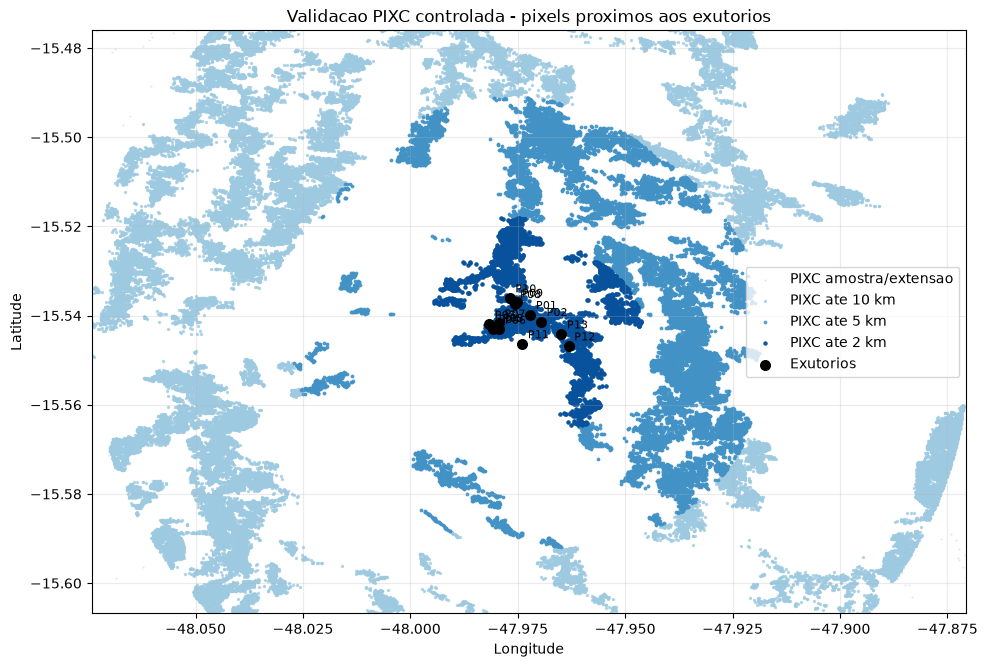

In [13]:
fig, ax = plt.subplots(figsize=(10, 9))
try:
    points_plot = points_gdf.to_crs('EPSG:4326')
    pix_plot = pix_m.to_crs('EPSG:4326')
    pix_10km = pix_m[pix_m.geometry.within(union_buffers[10000])].to_crs('EPSG:4326')
    pix_5km = pix_m[pix_m.geometry.within(union_buffers[5000])].to_crs('EPSG:4326')
    pix_2km = pix_m[pix_m.geometry.within(union_buffers[2000])].to_crs('EPSG:4326')

    sample = pix_plot.sample(min(len(pix_plot), 6000), random_state=42) if len(pix_plot) > 6000 else pix_plot
    sample.plot(ax=ax, color='#bdbdbd', markersize=0.5, alpha=0.25, label='PIXC amostra/extensao')
    if not pix_10km.empty:
        pix_10km.plot(ax=ax, color='#9ecae1', markersize=2, alpha=0.7, label='PIXC ate 10 km')
    if not pix_5km.empty:
        pix_5km.plot(ax=ax, color='#4292c6', markersize=3, alpha=0.8, label='PIXC ate 5 km')
    if not pix_2km.empty:
        pix_2km.plot(ax=ax, color='#08519c', markersize=5, alpha=0.9, label='PIXC ate 2 km')

    points_plot.plot(ax=ax, color='black', markersize=48, label='Exutorios', zorder=5)
    for _, row in points_plot.iterrows():
        ax.annotate(row['id'], (row.geometry.x, row.geometry.y), xytext=(4, 4), textcoords='offset points', fontsize=8)

    minx, miny, maxx, maxy = points_plot.total_bounds
    pad_x = max((maxx - minx) * 5, 0.06)
    pad_y = max((maxy - miny) * 5, 0.06)
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_title('Validacao PIXC controlada - pixels proximos aos exutorios')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_FIGURE, dpi=180)
    logging.info('Figura salva: %s', OUTPUT_FIGURE)
    print('OK figura salva:', OUTPUT_FIGURE)
    plt.show()
except Exception as exc:
    logging.exception('Falha ao gerar figura PIXC')
    raise RuntimeError('FALHA: nao foi possivel gerar a figura de validacao PIXC.') from exc


## Interpretação e limitações

`suporte_pixc = sim` significa que há pixel SWOT válido a até 500 m do exutório. `nao` indica ausência de pixel próximo dentro desse limiar. `indeterminado` aparece quando há proximidade, mas flags ou qualidade impedem interpretação segura.

A interpretação ainda é preliminar: o notebook não substitui uma análise hidrológica completa, não valida todas as flags do produto e usa apenas um grânulo PIXC.

## Recomendação do próximo passo

Se o PIXC apresentar pixels próximos, avançar para leitura mais cuidadosa das flags/classes e eventual recorte temporal. Se não apresentar pixels próximos, registrar que a área tem cobertura potencial por bounding box, mas sem observabilidade direta nos produtos testados, e só testar outro PIXC com justificativa espacial clara.